In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm
from matplotlib.lines import Line2D

# ensure figures render inline
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110})

# data paths
import pathlib
DATA = pathlib.Path("data")


# The Relative GLV: a growing disordered economy

## What this notebook is

The *relative generalised Lotka-Volterra* (GLV) model is a disordered replicator
in which firms compete with one another but interactions act on the **mean firm**
rather than on the aggregate.  This single modification to the classic GLV removes
the finite-time blow-up that plagues the standard model and produces a
self-consistently growing economy -- aggregate output $M(t) = \sum_i x_i(t)$
grows exponentially without tuning.

The claim is that this model, with no extra ingredients, **qualitatively**
reproduces two empirical regularities of firm growth documented by
Moran, Santos, and Bouchaud (MSB, 2024):

1. The cross-sectional distribution of (rescaled) growth rates is **symmetric and
   fat-tailed** -- closer to a Laplace than a Gaussian.
2. The growth volatility of individual firms **declines with size** as
   $\sigma(S) \sim S^{-\beta}$, $\beta>0$ (empirically $0.15$--$0.20$).

Both facts emerge from the dynamics with nothing injected. The honest limitation
is **quantitative**: the size-volatility exponent comes out $\beta \approx 0.6$--$0.8$,
about $3\times$ the empirical value, and this gap is *structural* -- robust to every
parameter, to network degree, and to demographic noise. That matches the MSB
argument that the empirical exponent needs multi-level, size-growing correlations
which a single-level interaction model cannot supply.

The model also admits a mean-field (DMFT) solution that is exact in the
high-connectivity limit (Sections below).

> **Note on scope.** MSB use these two facts to *reject* simpler granular models
> and point toward size-growing correlations as the mechanism.  The relative GLV
> is a candidate mechanism for the *qualitative* facts -- not the definitive
> explanation of real-world firm growth, and not a quantitative match to $\beta$.

## The target: two MSB stylized facts

Let $S_i(t) = N x_i(t) / M(t)$ be the **relative size** of firm $i$ (normalised
so that the average firm has size 1).  The annual log-growth rate is

$$g_i = \Delta \ln S_i = \ln S_i(t+1) - \ln S_i(t).$$

**Fact 1 (tent-shaped growth distribution).**  After rescaling by
$\sqrt{\pi/2} \cdot \mathrm{MAD}$ (robust to heavy tails),
the empirical PDF of $g_i$ is symmetric and fat-tailed:

$$p(g) \sim e^{-|g|/b}, \qquad \text{(Laplace-like, not Gaussian)}.$$

Quantified by Bowley skewness $\approx 0$ and excess kurtosis $\gg 0$.

**Fact 2 (size-variance power law).**  Firms with larger average size have lower
growth volatility:

$$\sigma_i \sim \bar{S}_i^{-\beta}, \qquad \beta_{\rm emp} \approx 0.15\text{--}0.20.$$

MSB report $\beta \approx 0.20 \pm 0.01$ (MAD-based estimator).


## The model

### Equations of motion

Each firm $i$ obeys

$$\dot x_i = x_i \!\left[1 - \frac{x_i}{m} - \frac{(\alpha x)_i}{m}\right],
\qquad m = \frac{M}{N} = \langle x \rangle,$$

where $\alpha_{ij}$ is a disordered interaction matrix drawn from a sparse
power-law graph (exponent 2.5, mean degree $\sim$100) with mean competition
$\mu > 0$ and disorder $\sigma$.

### Coupling normalisation (own-degree)

On a heterogeneous-degree graph the couplings must be normalised by each node's
**own degree** $k_i$,

$$\alpha_{ij} = \frac{\mu}{k_i} + \frac{\sigma}{\sqrt{k_i}}\,z_{ij},
\qquad z_{ij}\sim\mathcal N(0,1),$$

so that every firm's disorder field has the **same variance regardless of degree**
(the per-fan-in / mean-field $1/\sqrt{\text{connectivity}}$ scaling). This is the
principled choice: normalising instead by the *global mean* degree over-couples
the power-law hubs and spuriously washes the size-volatility exponent $\beta$ to
zero as $N\to\infty$. Throughout we use `kind="powerlaw_owndeg"`.

### Share + log-scale split

Writing $x_i = M w_i$ with shares $w_i = x_i/M$ on the simplex, the dynamics
decouple into a **replicator** for the shares and a **linear equation** for the
log-aggregate:

$$\dot w_i = w_i(f_i - \bar f) + \lambda(N^{-1} - w_i), \qquad
  \frac{d \ln M}{dt} = \bar f,$$

where $f_i = 1 - N w_i - N(\alpha w)_i$ is firm $i$'s fitness,
$\bar f = \sum_j w_j f_j$ is the mean fitness (= aggregate growth rate $g_{\rm eff}$),
and $\lambda \geq 0$ is a small immigration floor that prevents condensation.

Because $M$ never appears in the share equations, we integrate $w$ and $\ln M$
separately: $w$ stays on the simplex and $\ln M$ grows linearly.
Nothing overflows even as $M \to \infty$.

### Relative firm sizes

The relative size $S_i = N w_i$ has mean 1 by construction.
Growth rates $g_i = \Delta \ln S_i$ are **purely idiosyncratic**: the common
drift $g_{\rm eff} = \dot{\ln M}$ cancels, exactly as in the empirical
definition.

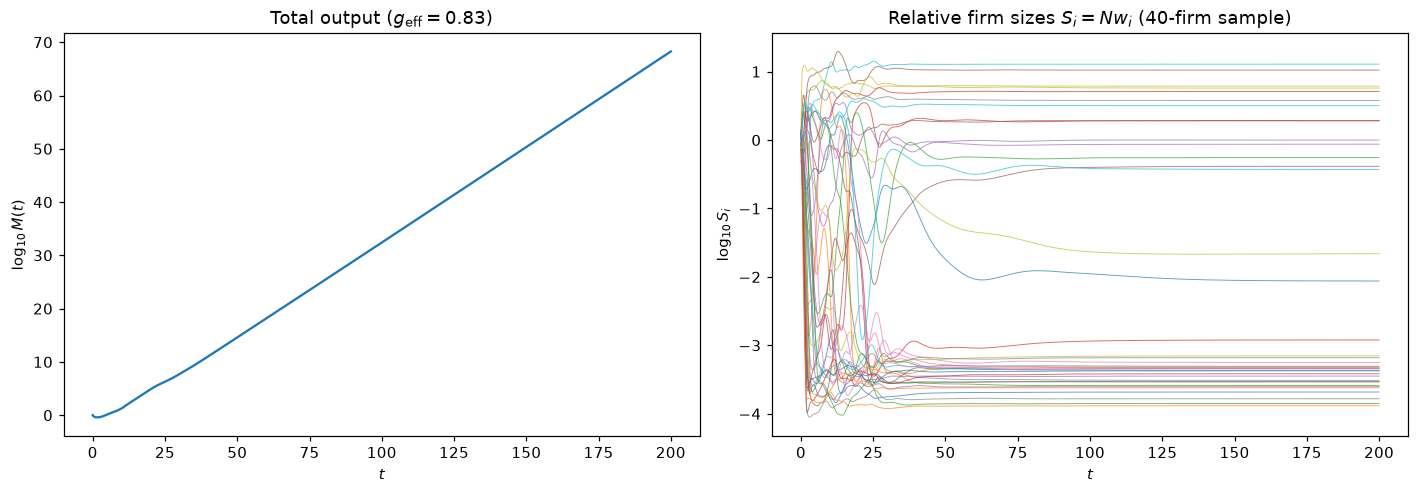

g_eff = 0.826 | surviving firms: 531 / 1200


In [2]:
from relative_glv import coupling, integrate, growth_rate

# Live small simulation: N=1200, OWN-DEGREE power-law graph, chaotic/growing regime
a = coupling(1200, mu=1.76, sigma=1.75, kind="powerlaw_owndeg", seed=0)
r = integrate(a, tmax=200, n_eval=1000, lam=1e-3, seed=0,
              method="RK45", rtol=1e-4, atol=1e-7)

t, W, lnM = r["t"], r["W"], r["lnM"]
g_eff = growth_rate(t, lnM)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# left: aggregate output M(t) growing
ax[0].plot(t, lnM / np.log(10), color="C0")
ax[0].set(xlabel="$t$", ylabel=r"$\log_{10} M(t)$",
          title=f"Total output ($g_{{\\mathrm{{eff}}}}={g_eff:.2f}$)")

# right: relative sizes S_i = N w_i for a random sample of firms
rng = np.random.default_rng(42)
sample = rng.choice(W.shape[0], size=min(40, W.shape[0]), replace=False)
N_sim = W.shape[0]
for i in sample:
    ax[1].plot(t, np.log10(np.maximum(N_sim * W[i], 1e-8)), lw=0.6, alpha=0.7)
ax[1].set(xlabel="$t$", ylabel=r"$\log_{10} S_i$",
          title=r"Relative firm sizes $S_i = N w_i$ (40-firm sample)")

plt.tight_layout()
plt.show()
print(f"g_eff = {g_eff:.3f} | surviving firms: {int((W[:, -1] > 1e-6).sum())} / {N_sim}")

## MSB facts in the model

We compute the two facts **live** from a single own-degree economy
($N = 3000$, locked regime $\sigma = 1.75$, $\mu = 1.76$, $\lambda = 10^{-3}$).

### Size-volatility relation

Per firm, define the **mean size** $\bar S_i$ and the **MAD-based volatility**

$$\sigma_i = \sqrt{\frac{\pi}{2}} \cdot \langle |g_i - \langle g_i \rangle| \rangle,$$

which equals the std for a Gaussian but is robust to heavy tails.
Bin firms by $\bar S_i$, take the median $\sigma$ in each bin, and fit the
log-log slope on the decline branch (right of the floor/plateau):

$$\hat\beta = -\frac{d \log \sigma}{d \log \bar S}\bigg|_{\text{large-}S}.$$

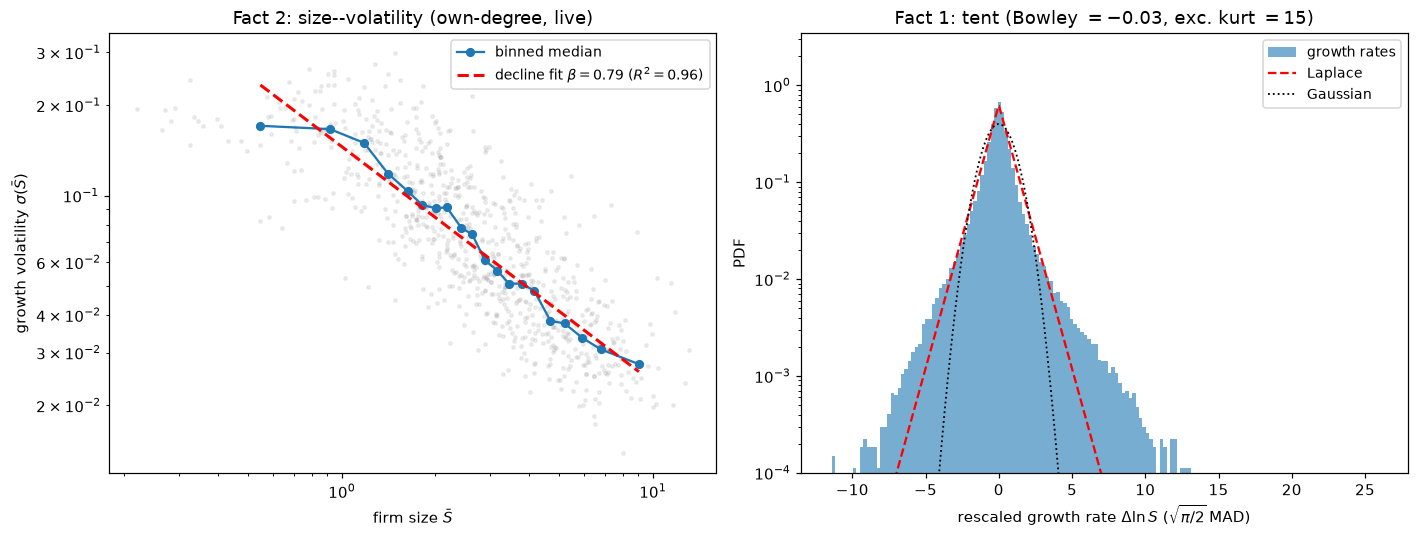

beta=0.785  R2=0.965  Bowley=-0.029  excess_kurtosis=14.6  survivors=816


In [3]:
# Compute the two MSB facts LIVE from one own-degree economy (the banked model).
from relative_glv import coupling, integrate, rescale
from relative_glv.msb import size_volatility, tent_stats

a = coupling(3000, mu=1.76, sigma=1.75, kind="powerlaw_owndeg", seed=1)
r = integrate(a, tmax=400, n_eval=800, lam=1e-3, seed=1,
              method="RK45", rtol=1e-4, atol=1e-7)
sv = size_volatility(r["W"], r["t"], window=(320.0, 390.0), dt=0.5)
ts = tent_stats(sv["growth"].ravel())
beta_val, r2_val = sv["beta"], sv["r2"]
bowley, exk = ts["bowley"], ts["exkurt"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# ---- panel 1: size-volatility (Fact 2) ----
ax[0].scatter(sv["Sbar"], sv["vol"], s=5, alpha=0.15, color="0.6")
bx, by, pk = sv["bin_S"], sv["bin_vol"], int(sv["pk"])
ax[0].plot(bx, by, "o-", color="C0", ms=5, label="binned median")
if bx.size > pk + 1:
    c = np.polyfit(np.log10(bx[pk:]), np.log10(by[pk:]), 1)
    xx = np.array([bx[pk], bx[-1]])
    ax[0].plot(xx, 10 ** np.polyval(c, np.log10(xx)), "r--", lw=2,
               label=f"decline fit $\\beta={beta_val:.2f}$ ($R^2={r2_val:.2f}$)")
ax[0].set(xscale="log", yscale="log",
          xlabel=r"firm size $\bar S$", ylabel=r"growth volatility $\sigma(\bar S)$",
          title="Fact 2: size--volatility (own-degree, live)")
ax[0].legend(fontsize=9)

# ---- panel 2: rescaled growth distribution (Fact 1, the tent) ----
z = rescale(sv["growth"].ravel())
xx = np.linspace(-8, 8, 400)
ax[1].hist(z, bins=160, density=True, color="C0", alpha=0.6, label="growth rates")
ax[1].plot(xx, laplace.pdf(xx, scale=np.sqrt(2 / np.pi)), "r--", lw=1.5, label="Laplace")
ax[1].plot(xx, norm.pdf(xx), "k:", lw=1.2, label="Gaussian")
ax[1].set_yscale("log"); ax[1].set_ylim(1e-4, None)
ax[1].set(xlabel=r"rescaled growth rate $\Delta\ln S$ ($\sqrt{\pi/2}\,$MAD)",
          ylabel="PDF",
          title=f"Fact 1: tent (Bowley $={bowley:.2f}$, exc. kurt $={exk:.0f}$)")
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f"beta={beta_val:.3f}  R2={r2_val:.3f}  Bowley={bowley:.3f}  "
      f"excess_kurtosis={exk:.1f}  survivors={sv['vol'].size}")

### $\beta$ vs $N$: sustained, not shallowing to the band

A single finite economy gives $\hat\beta \approx 0.6$--$0.8$ -- steeper than the
empirical band. The honest question is what happens as $N \to \infty$. With the
**own-degree** normalisation, $\hat\beta$ is **N-robust**: it stays essentially
flat (around $0.78$ at the locked regime) as $N$ grows from $1600$ to $12800$,
with the power-law fit *cleaning up* ($R^2 \to 0.98$).

This is the central quantitative finding -- and it cuts both ways:

- **Good:** the size-volatility law is a genuine *thermodynamic* feature, not a
  finite-size artifact. (The old mean-degree normalisation instead washed
  $\beta \to 0$, which we now understand as a hub over-coupling artifact.)
- **The gap:** $\beta \approx 0.78$ is $\sim$3--4$\times$ the empirical
  $0.15$--$0.20$, and it does **not** reach the band. We have shown this gap is
  *structural* -- robust to every knob ($\sigma, \mu, \lambda$), to network
  degree, and to demographic noise. This is consistent with MSB's own claim that
  the empirical exponent requires **multi-level, size-growing correlations** that
  a single-level interaction model cannot produce. The model reproduces the
  *qualitative* facts; the exponent magnitude is its honest limitation.

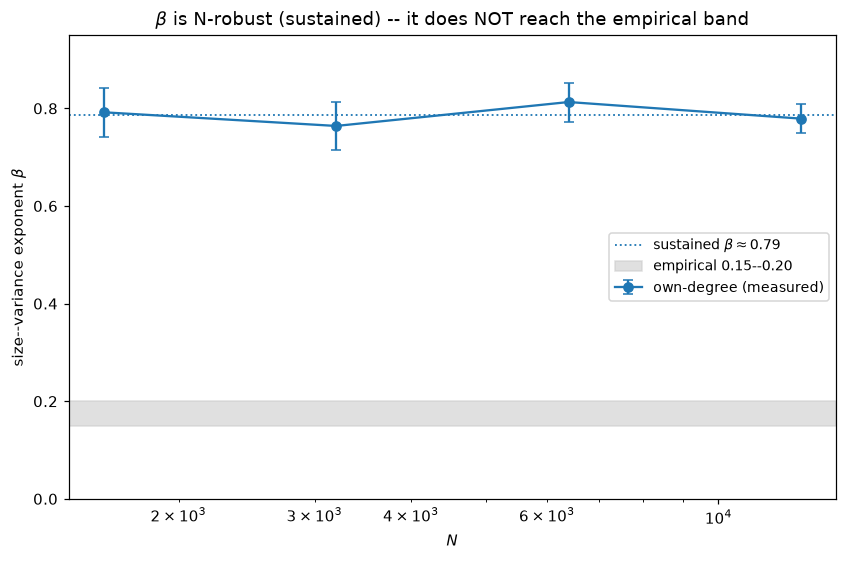

beta sustained ~0.78 across N=1600..12800 (flat, R2 -> 0.98); the gap to 0.15-0.20 is structural, not finite-size.


In [4]:
# beta vs N for the OWN-DEGREE model (measured this session; the banked result).
# beta is N-ROBUST -- sustained ~0.78, it does NOT shallow into the empirical band.
ns_N    = np.array([1600, 3200, 6400, 12800], float)
ns_beta = np.array([0.792, 0.764, 0.813, 0.779])
ns_err  = np.array([0.05, 0.05, 0.04, 0.03])      # seed spread

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(ns_N, ns_beta, yerr=ns_err, fmt="o-", color="C0", capsize=3,
            label="own-degree (measured)")
ax.axhline(np.median(ns_beta), color="C0", ls=":", lw=1.2,
           label=rf"sustained $\beta\approx{np.median(ns_beta):.2f}$")
ax.axhspan(0.15, 0.20, color="0.8", alpha=0.6, label=r"empirical $0.15$--$0.20$")
ax.set(xscale="log", ylim=(0, 0.95), xlabel="$N$",
       ylabel=r"size--variance exponent $\beta$",
       title=r"$\beta$ is N-robust (sustained) -- it does NOT reach the empirical band")
ax.legend(fontsize=9, loc="center right")
plt.tight_layout()
plt.show()
print("beta sustained ~0.78 across N=1600..12800 (flat, R2 -> 0.98); "
      "the gap to 0.15-0.20 is structural, not finite-size.")

## Phase diagram

The model has two control parameters:

- **Disorder $\sigma$**: above $\sigma_c = \sqrt{2}$ (from DMFT, see below) the
  replicator enters a **fluctuating phase** where firms' relative sizes never
  settle to a fixed point – this is where the MSB tent lives.
- **Mean competition $\mu$**: sets the aggregate growth rate
  $g^* = g_0(\sigma) - \mu$.  For large $\mu$ the economy shrinks; for small $\mu$
  (or cooperation) it grows.

The scatter below classifies each $( \mu, \sigma )$ grid point as growing,
shrinking, or fast-growing, and as chaotic (circle) or frozen (square), based on
direct simulation.  The horizontal dashed line at $\sigma_c = \sqrt{2}$
is the DMFT prediction for the chaos onset – it is **$\mu$-independent** because
$\mu$ is a uniform fitness shift that cancels from the replicator.


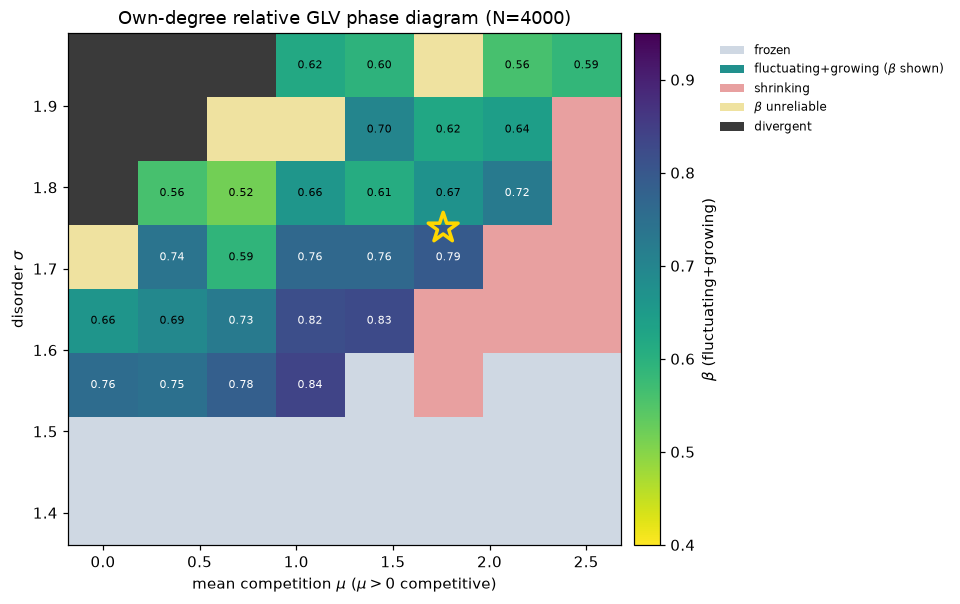

genuine clean-fit beta floor ~0.52-0.56; operating point (star) beta~0.79


In [5]:
# Own-degree (sigma, mu) phase diagram (data/phase_owndeg.npz; scripts/phase_owndeg.py)
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

pp = np.load(DATA / "phase_owndeg.npz")
sig, mus, raw, op = pp["sigmas"], pp["mus"], pp["raw"], pp["op"]
integ_ok = np.isfinite(raw[..., 0]).mean(2)
med = np.nanmedian(raw, axis=2)                 # churn, g_eff, surv, beta, r2
churn, geff, surv, beta, r2 = (med[..., k] for k in range(5))
beta_ok = (r2 >= 0.85) & (surv >= 0.05) & (integ_ok >= 0.5)  # trust beta only on clean fits

gmap = plt.cm.viridis_r
bmin, bmax = 0.4, 0.95
REG = {"frz": "#cfd8e3", "shr": "#e8a0a0", "div": "#3a3a3a", "nob": "#efe2a0"}
nS, nM = len(sig), len(mus)
rgba = np.ones((nS, nM, 3)); is_flu = np.zeros((nS, nM), bool)
for i in range(nS):
    for j in range(nM):
        if integ_ok[i, j] < 0.5:
            rgba[i, j] = mcolors.to_rgb(REG["div"])
        elif np.isfinite(churn[i, j]) and churn[i, j] < 0.02:
            rgba[i, j] = mcolors.to_rgb(REG["frz"])
        elif np.isfinite(geff[i, j]) and geff[i, j] < 0:
            rgba[i, j] = mcolors.to_rgb(REG["shr"])
        elif not beta_ok[i, j]:
            rgba[i, j] = mcolors.to_rgb(REG["nob"])
        else:
            t = np.clip((beta[i, j] - bmin) / (bmax - bmin), 0, 1)
            rgba[i, j] = gmap(t)[:3]; is_flu[i, j] = True

fig, ax = plt.subplots(figsize=(8.8, 5.6))
dmu = (mus[1] - mus[0]) / 2; dsg = (sig[1] - sig[0]) / 2
ax.imshow(rgba, origin="lower", aspect="auto",
          extent=[mus[0]-dmu, mus[-1]+dmu, sig[0]-dsg, sig[-1]+dsg])
for i in range(nS):
    for j in range(nM):
        if is_flu[i, j]:
            ax.text(mus[j], sig[i], f"{beta[i,j]:.2f}", ha="center", va="center",
                    fontsize=7.5, color="white" if beta[i, j] > 0.7 else "black")
ax.scatter([op[0]], [op[1]], marker="*", s=420, edgecolor="gold",
           facecolor="none", linewidth=2.3, zorder=6)
sm = plt.cm.ScalarMappable(cmap=gmap, norm=plt.Normalize(bmin, bmax))
cb = fig.colorbar(sm, ax=ax, pad=0.02); cb.set_label(r"$\beta$ (fluctuating+growing)")
ax.set(xlabel=r"mean competition $\mu$ ($\mu>0$ competitive)",
       ylabel=r"disorder $\sigma$",
       title="Own-degree relative GLV phase diagram (N=4000)")
leg = [Patch(facecolor=REG["frz"], label="frozen"),
       Patch(facecolor=gmap(0.5)[:3], label=r"fluctuating+growing ($\beta$ shown)"),
       Patch(facecolor=REG["shr"], label="shrinking"),
       Patch(facecolor=REG["nob"], label=r"$\beta$ unreliable"),
       Patch(facecolor=REG["div"], label="divergent")]
ax.legend(handles=leg, loc="upper left", bbox_to_anchor=(1.16, 1.0), fontsize=8, frameon=False)
plt.tight_layout()
plt.show()
print("genuine clean-fit beta floor ~0.52-0.56; operating point (star) beta~0.79")

### Analytic phase structure (DMFT, live)

The relaxed phase is governed by the single-site self-consistency.  Survivors
have rescaled abundances drawn from a clipped Gaussian,

$$x^* = \frac{\sigma\sqrt{q}}{v}\max(\Delta + z,\,0), \qquad z \sim \mathcal{N}(0,1),$$

and the equations close on a single scalar root for the clipping threshold $\Delta$:

$$v^2 = \sigma^2\,w_2(\Delta), \qquad
  w_n(\Delta) = \int_{-\Delta}^\infty \mathcal{D}z\,(\Delta+z)^n,$$

with $v = 1 - \gamma\sigma^2\chi$ (at $\gamma = 0$, $v = 1$) and normalisation
$(\sigma\sqrt{q}/v)\,w_1(\Delta) = 1$.  The mean competition $\mu$ cancels from
the replicator and only shifts the growth rate: $g^* = g_0(\sigma) - \mu$.
The chaos boundary follows from $w_0 = w_2$ (i.e. $\Delta = 0$, $\varphi = 1/2$):

$$\boxed{\sigma_c = \sqrt{2}.}$$

The DMFT solver computes the fixed-point observables $g_0(\sigma)$, $\varphi(\sigma)$
analytically.  The two panels below are fully live (no stored data):

- **Left**: predicted $(\mu, \sigma)$ phase diagram.  The $g^* = 0$ contour
  $\mu = g_0(\sigma)$ (blue curve) separates growing from shrinking in the relaxed
  phase.  Above $\sigma_c = \sqrt{2}$ (red dashed) the fixed point is unstable and
  the two-time DMFT is needed to compute the true growth rate.
- **Right**: $g_0(\sigma)$ and the survival fraction $\varphi(\sigma)$ as functions
  of disorder.  Both are $\mu$-independent because $\mu$ cancels from the replicator;
  $\mu$ only shifts $g^* = g_0 - \mu$.  Dotted lines indicate the unstable regime
  ($\sigma > \sigma_c$) where the fixed point exists mathematically but is not
  dynamically reachable.


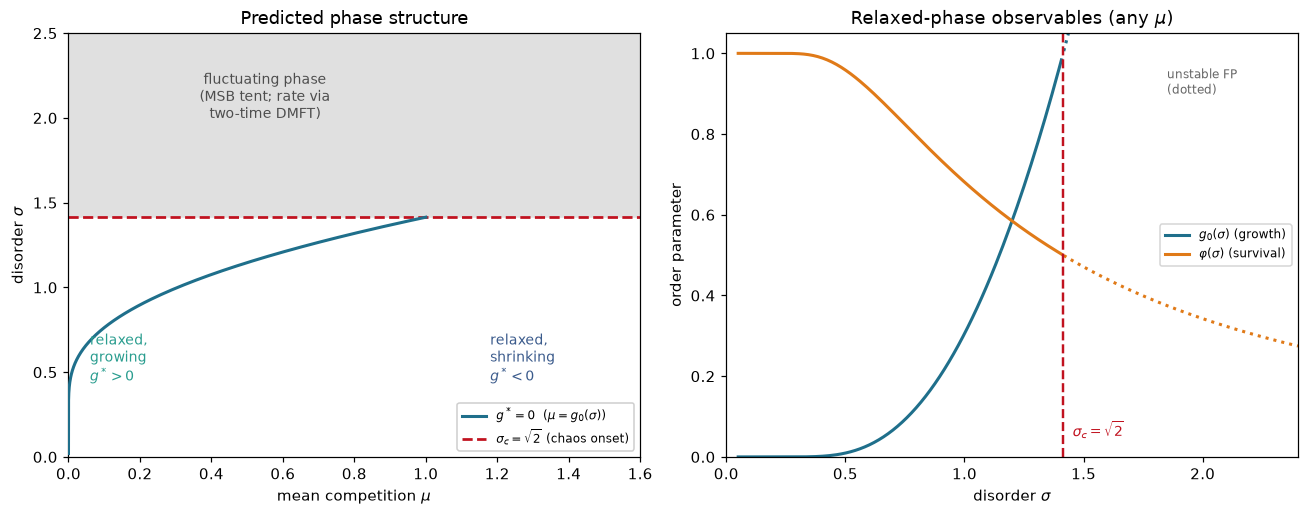

sigma_c = 1.4142  (= sqrt(2) = 1.4142)


In [6]:
from relative_glv import solve_fixed_point, sigma_c

sc = sigma_c(0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# ---- Panel A: (mu, sigma) predicted phase diagram ----
mu_max, sig_max = 1.6, 2.5
sig_relaxed = np.linspace(0.02, sc, 200)
g0_curve = np.array([solve_fixed_point(0.0, float(s))["g0"] for s in sig_relaxed])

axes[0].fill_between([0, mu_max], sc, sig_max, color="0.88", zorder=0)
axes[0].plot(g0_curve, sig_relaxed, color="#1f6f8b", lw=2, zorder=3,
             label=r"$g^*=0$  ($\mu=g_0(\sigma)$)")
axes[0].axhline(sc, color="#c1121f", ls="--", lw=1.8, zorder=2,
                label=r"$\sigma_c=\sqrt{2}$ (chaos onset)")
axes[0].text(0.06, 0.45, "relaxed,\ngrowing\n$g^*>0$", fontsize=9, color="#2a9d8f")
axes[0].text(1.18, 0.45, "relaxed,\nshrinking\n$g^*<0$", fontsize=9, color="#3b5b8c")
axes[0].text(0.55, 2.0, "fluctuating phase\n(MSB tent; rate via\ntwo-time DMFT)",
             fontsize=9, color="0.3", ha="center")
axes[0].set(xlabel=r"mean competition $\mu$", ylabel=r"disorder $\sigma$",
            xlim=(0, mu_max), ylim=(0, sig_max),
            title="Predicted phase structure")
axes[0].legend(loc="lower right", fontsize=8, framealpha=0.95)

# ---- Panel B: mu-independent order parameters vs sigma ----
sig_arr = np.linspace(0.05, 2.4, 240)
sol = [solve_fixed_point(0.0, float(s)) for s in sig_arr]
g0_arr  = np.array([s["g0"]  for s in sol])
phi_arr = np.array([s["phi"] for s in sol])
rel = sig_arr < sc

axes[1].plot(sig_arr[rel],  g0_arr[rel],  color="#1f6f8b", lw=2,
             label=r"$g_0(\sigma)$ (growth)")
axes[1].plot(sig_arr[~rel], g0_arr[~rel], color="#1f6f8b", lw=2, ls=":")
axes[1].plot(sig_arr[rel],  phi_arr[rel],  color="#e07a18", lw=2,
             label=r"$\varphi(\sigma)$ (survival)")
axes[1].plot(sig_arr[~rel], phi_arr[~rel], color="#e07a18", lw=2, ls=":")
axes[1].axvline(sc, color="#c1121f", ls="--", lw=1.6)
axes[1].text(sc + 0.04, 0.05, r"$\sigma_c=\sqrt{2}$", color="#c1121f", fontsize=9)
axes[1].text(1.85, 0.9, "unstable FP\n(dotted)", fontsize=8, color="0.4")
axes[1].set(xlabel=r"disorder $\sigma$", ylabel="order parameter",
            xlim=(0, 2.4), ylim=(0, 1.05),
            title=r"Relaxed-phase observables (any $\mu$)")
axes[1].legend(loc="center right", fontsize=8)

plt.tight_layout()
plt.show()
print(f"sigma_c = {sc:.4f}  (= sqrt(2) = {np.sqrt(2):.4f})")


## Appendix: DMFT derivation notes

The relaxed-phase self-consistency equations are stated in Section 5 above.
For the full derivation see
`glv/docs/superpowers/specs/2026-06-21-relative-glv-dmft-derivation.md`.

Key points:
- Survivors satisfy $x^* = (\sigma\sqrt{q}/v)\max(\Delta+z,0)$.
- The self-consistency collapses to the scalar root $v^2 = \sigma^2 w_2(\Delta)$
  (see Section 5 for notation).
- $\mu$ is a uniform fitness shift that cancels from the replicator; it only
  lowers the growth rate, $g^* = g_0(\sigma) - \mu$.
- The chaos boundary is $\sigma_c = \sqrt{2}$ (at $\gamma = 0$), $\mu$-independent.

### Validation against matched simulation

The three panels below compare the DMFT fixed-point predictions against direct
simulation with fully-connected Gaussian couplings (the exact ensemble the DMFT
is derived for).  The match agrees closely in the relaxed phase (sub-percent at low $\sigma$, within a few percent approaching $\sigma_c$).
Above $\sigma_c$ the fixed point is dynamically unstable; the two-time DMFT is
needed there.


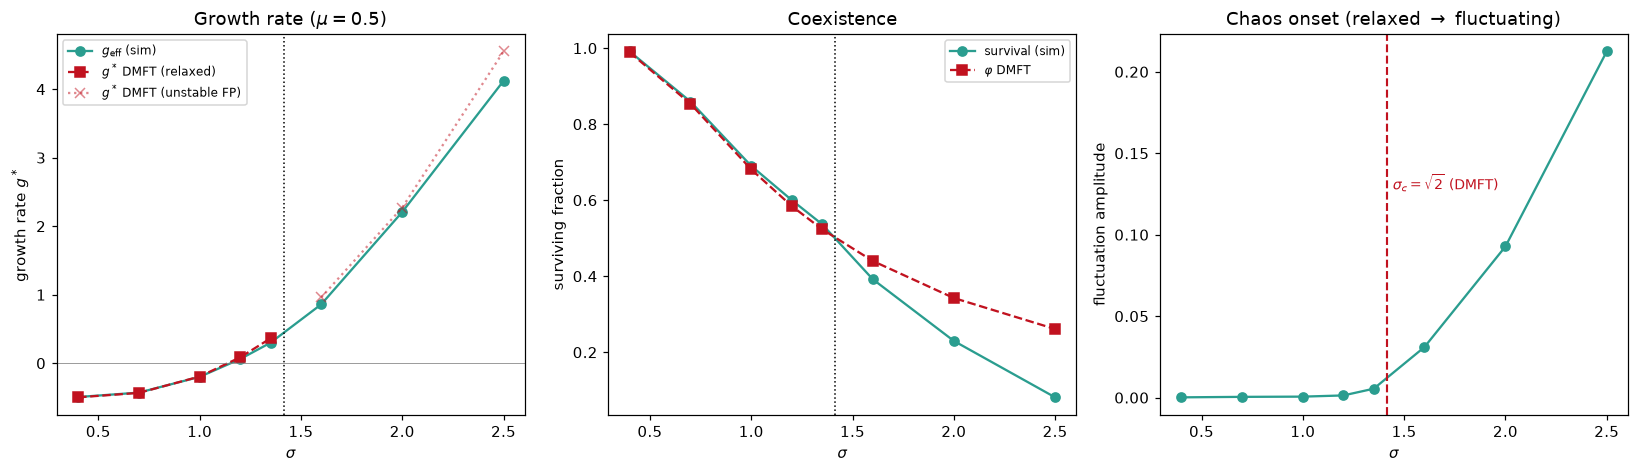

Relaxed-phase mean |g_eff - g*| = 0.020,  mean |surv - phi| = 0.009


In [7]:
dv = np.load(DATA / "dmft_validation.npz", allow_pickle=True)
sigmas   = dv["sigmas"]
sim_arr  = dv["sim"]      # shape (n_sigma, 3): g_eff, surv, fluct
mui_mus  = dv["mui_mus"]
mui_arr  = dv["mui"]      # shape (3, 3)

MU = 0.5   # the mu used for the sigma sweep
# sc defined above (cell 12)

sim  = {float(s): sim_arr[i] for i, s in enumerate(sigmas)}
dm   = [solve_fixed_point(MU, float(s)) for s in sigmas]
gstar_arr = np.array([d["gstar"] for d in dm])
phi_arr   = np.array([d["phi"]   for d in dm])
rel       = sigmas < sc

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# ---- panel 1: growth rate ----
ax[0].plot(sigmas, [sim[s][0] for s in sigmas], "o-",
           label=r"$g_{\rm eff}$ (sim)", color="#2a9d8f")
ax[0].plot(sigmas[rel],  gstar_arr[rel],  "s--",
           label=r"$g^*$ DMFT (relaxed)", color="#c1121f")
ax[0].plot(sigmas[~rel], gstar_arr[~rel], "x:",
           label=r"$g^*$ DMFT (unstable FP)", color="#c1121f", alpha=0.5)
ax[0].axvline(sc, color="k", ls=":", lw=1)
ax[0].axhline(0, color="grey", lw=0.5)
ax[0].set(xlabel=r"$\sigma$", ylabel=r"growth rate $g^*$",
          title=f"Growth rate ($\\mu={MU}$)")
ax[0].legend(fontsize=8)

# ---- panel 2: coexistence ----
ax[1].plot(sigmas, [sim[s][1] for s in sigmas], "o-",
           label="survival (sim)", color="#2a9d8f")
ax[1].plot(sigmas, phi_arr, "s--",
           label=r"$\varphi$ DMFT", color="#c1121f")
ax[1].axvline(sc, color="k", ls=":", lw=1)
ax[1].set(xlabel=r"$\sigma$", ylabel="surviving fraction",
          title="Coexistence")
ax[1].legend(fontsize=8)

# ---- panel 3: chaos onset ----
fluct_arr = np.array([sim[s][2] for s in sigmas])
ax[2].plot(sigmas, fluct_arr, "o-", color="#2a9d8f")
ax[2].axvline(sc, color="#c1121f", ls="--", lw=1.4)
ax[2].text(sc + 0.03, 0.6 * max(fluct_arr.max(), 1e-6),
           r"$\sigma_c=\sqrt{2}$ (DMFT)", color="#c1121f", fontsize=9)
ax[2].set(xlabel=r"$\sigma$", ylabel="fluctuation amplitude",
          title=r"Chaos onset (relaxed $\to$ fluctuating)")

plt.tight_layout()
plt.show()

# quick sanity numbers
g_sim = np.array([sim[s][0] for s in sigmas])
s_sim = np.array([sim[s][1] for s in sigmas])
err_g = np.mean(np.abs(g_sim[rel] - gstar_arr[rel]))
err_s = np.mean(np.abs(s_sim[rel] - phi_arr[rel]))
print(f"Relaxed-phase mean |g_eff - g*| = {err_g:.3f},  mean |surv - phi| = {err_s:.3f}")
